# Diabetes Prediction: A Complete Machine Learning Workflow

## Objective
Build a machine learning model to predict diabetes from patient medical data, addressing real-world challenges:
- **Missing values** in the dataset
- **Noise and outliers** in measurements
- **Class imbalance** between diabetic and non-diabetic patients

## Dataset
The Pima Indians Diabetes Dataset contains medical records with features:
- Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
- Target: Outcome (0 = No diabetes, 1 = Diabetes)

## Step 1: Import Required Libraries

We'll use pandas for data manipulation, numpy for numerical operations, matplotlib/seaborn for visualization, and sklearn for machine learning.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Machine Learning - Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Handling Imbalanced Data
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Explore the Data

First, let's load the dataset and understand its structure.

In [2]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Dataset shape
print(f"\nDataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1} (plus 1 target variable)")

First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape: (768, 9)
Number of samples: 768
Number of features: 8 (plus 1 target variable)


In [3]:
# Dataset information
print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 3: Identify Data Quality Issues

### 3.1 Check for Missing Values

In [4]:
# Check for null values
print("Null values per column:")
print(df.isnull().sum())

print("\nImportant Discovery:")
print("While there are no 'null' values, medical features like Glucose, BloodPressure,")
print("SkinThickness, Insulin, and BMI have zero values, which are biologically impossible.")
print("These zeros are actually missing data!")

Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Important Discovery:
While there are no 'null' values, medical features like Glucose, BloodPressure,
SkinThickness, Insulin, and BMI have zero values, which are biologically impossible.
These zeros are actually missing data!


In [5]:
# Count zeros in problematic columns
columns_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Number of zero values (missing data):")
for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    percentage = (zero_count / len(df)) * 100
    print(f"{col}: {zero_count} ({percentage:.1f}%)")

Number of zero values (missing data):
Glucose: 5 (0.7%)
BloodPressure: 35 (4.6%)
SkinThickness: 227 (29.6%)
Insulin: 374 (48.7%)
BMI: 11 (1.4%)


### 3.2 Visualize Target Variable Distribution (Class Imbalance)

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class imbalance ratio: 1.87:1
Dataset is imbalanced - there are 1.87x more non-diabetic patients!


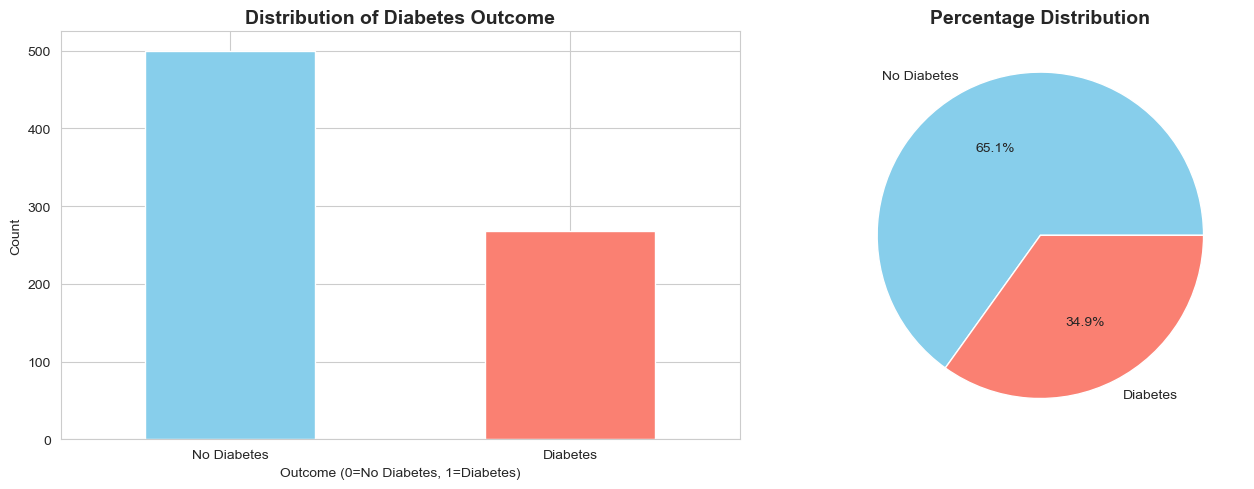

In [6]:
# Count of each class
print("Class distribution:")
print(df['Outcome'].value_counts())

# Calculate class imbalance ratio
class_counts = df['Outcome'].value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Dataset is imbalanced - there are {imbalance_ratio:.2f}x more non-diabetic patients!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribution of Diabetes Outcome', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   labels=['No Diabetes', 'Diabetes'],
                                   colors=['skyblue', 'salmon'])
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Step 4: Data Cleaning - Handle Missing Values

We'll replace zero values with median for each feature (median is robust to outliers).

In [7]:
# Create a copy for cleaning
df_clean = df.copy()

# Replace zeros with NaN in problematic columns
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean[columns_to_fix] = df_clean[columns_to_fix].replace(0, pd.NA)

print("Before imputation:")
print(df_clean[columns_to_fix].isnull().sum())

# Fill missing values with median
df_clean[columns_to_fix] = df_clean[columns_to_fix].fillna(df_clean[columns_to_fix].median())

print("\nAfter imputation:")
print(df_clean[columns_to_fix].isnull().sum())
print("\nAll missing values have been handled!")

Before imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

After imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

All missing values have been handled!


C:\Users\asusz\AppData\Local\Temp\ipykernel_8688\1394165807.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[columns_to_fix] = df_clean[columns_to_fix].fillna(df_clean[columns_to_fix].median())


## Step 5: Exploratory Data Analysis (EDA)

### 5.1 Feature Distributions

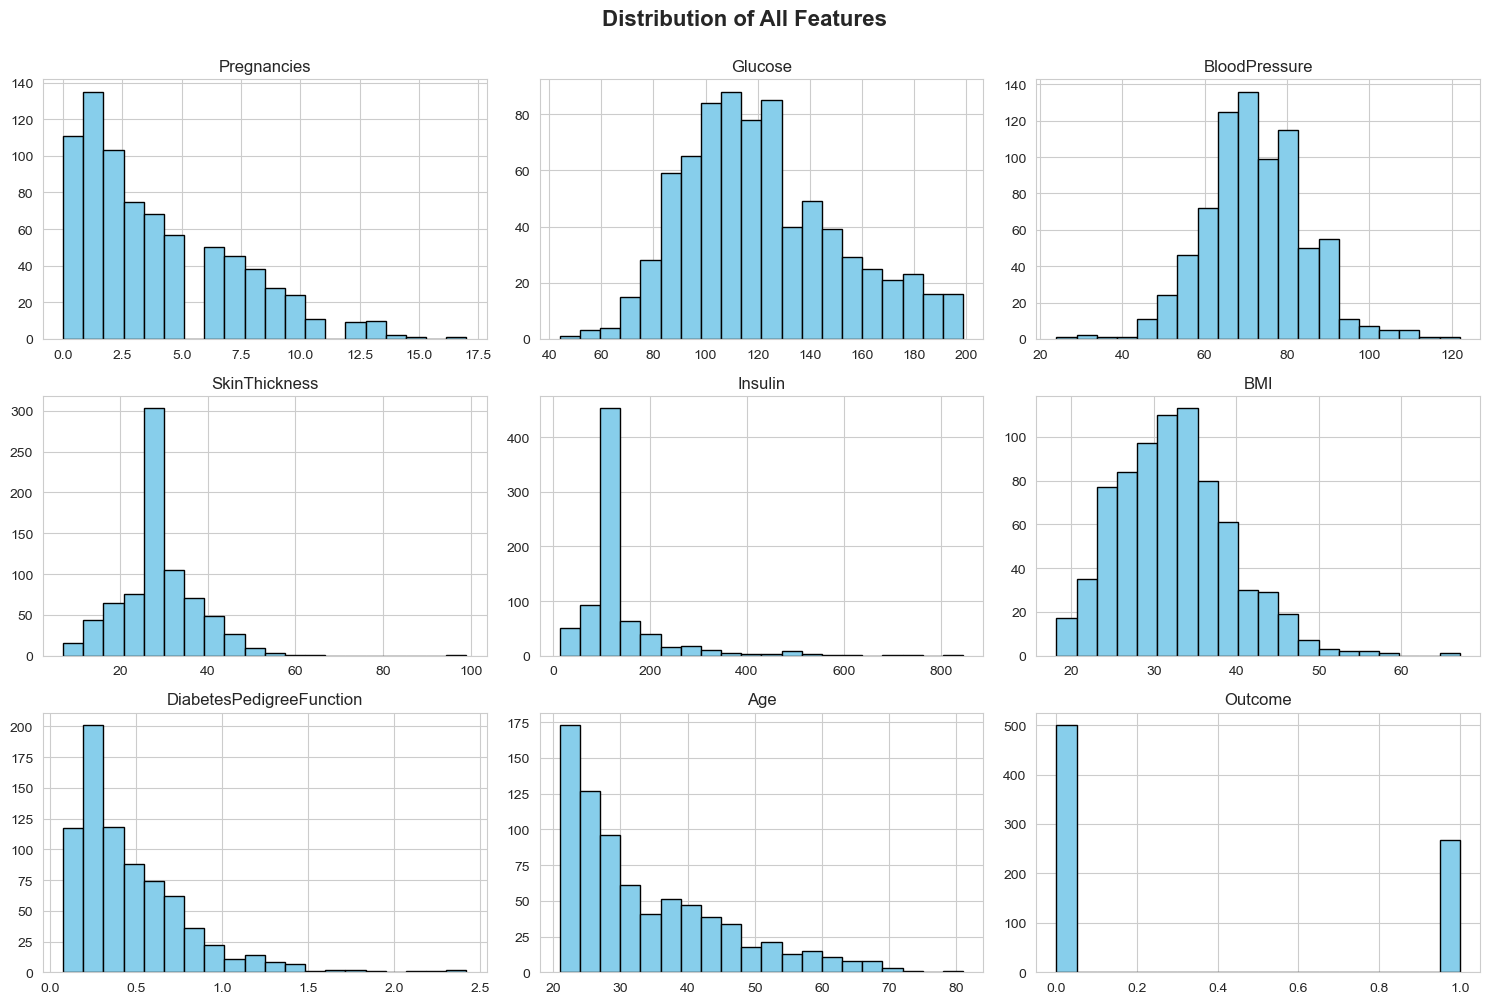

Observations:
- Most features show right-skewed distributions
- Age and Pregnancies are discrete variables
- Some features like Insulin show high variability


In [8]:
# Plot histograms for all features
df_clean.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Observations:")
print("- Most features show right-skewed distributions")
print("- Age and Pregnancies are discrete variables")
print("- Some features like Insulin show high variability")

### 5.2 Feature Correlations

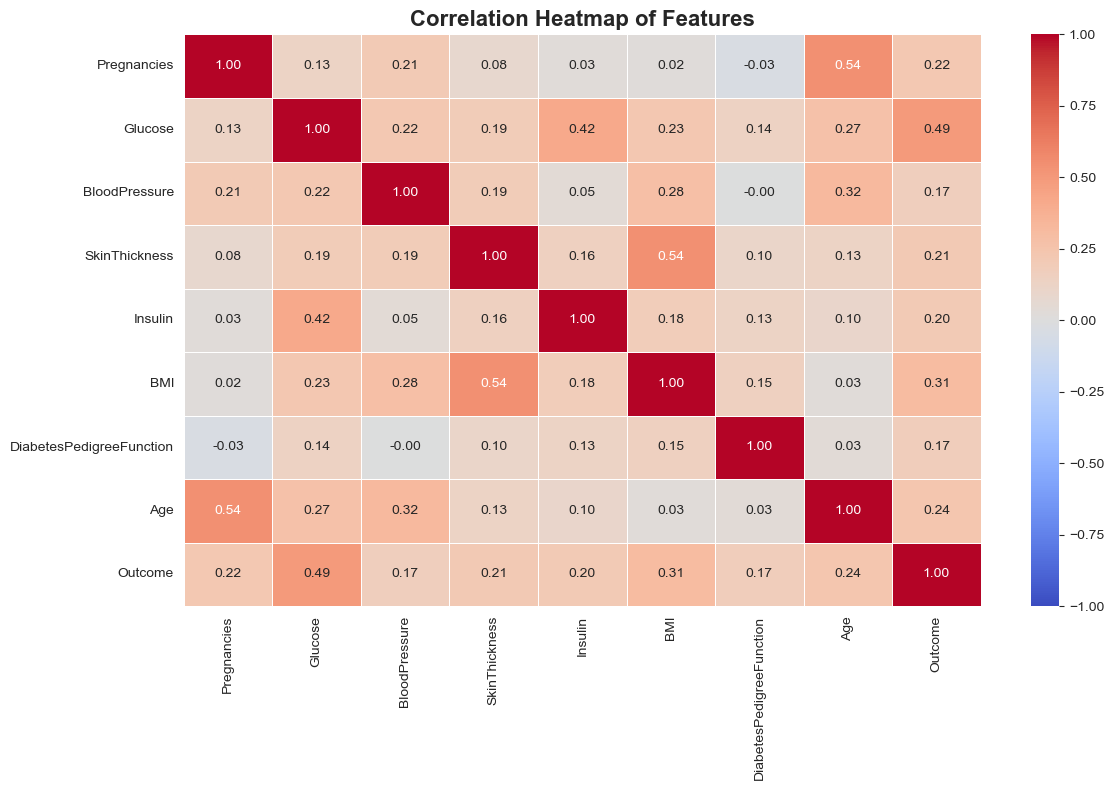


Key Correlations with Outcome (Diabetes):
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [9]:
# Calculate correlation matrix
correlation_matrix = df_clean.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Correlations with Outcome (Diabetes):")
outcome_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_corr[outcome_corr.index != 'Outcome'])

### 5.3 Feature Relationships with Target

C:\Users\asusz\AppData\Local\Temp\ipykernel_8688\535738096.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=feature, data=df_clean, palette='coolwarm', ax=axes[row, col])
C:\Users\asusz\AppData\Local\Temp\ipykernel_8688\535738096.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(['No Diabetes', 'Diabetes'])
C:\Users\asusz\AppData\Local\Temp\ipykernel_8688\535738096.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=feature, data=df_clean, palette='coolwarm', ax=axes[row, col])
C:\Users\asusz\AppData\Local\Temp\ipykernel_8688\535738096.py:11

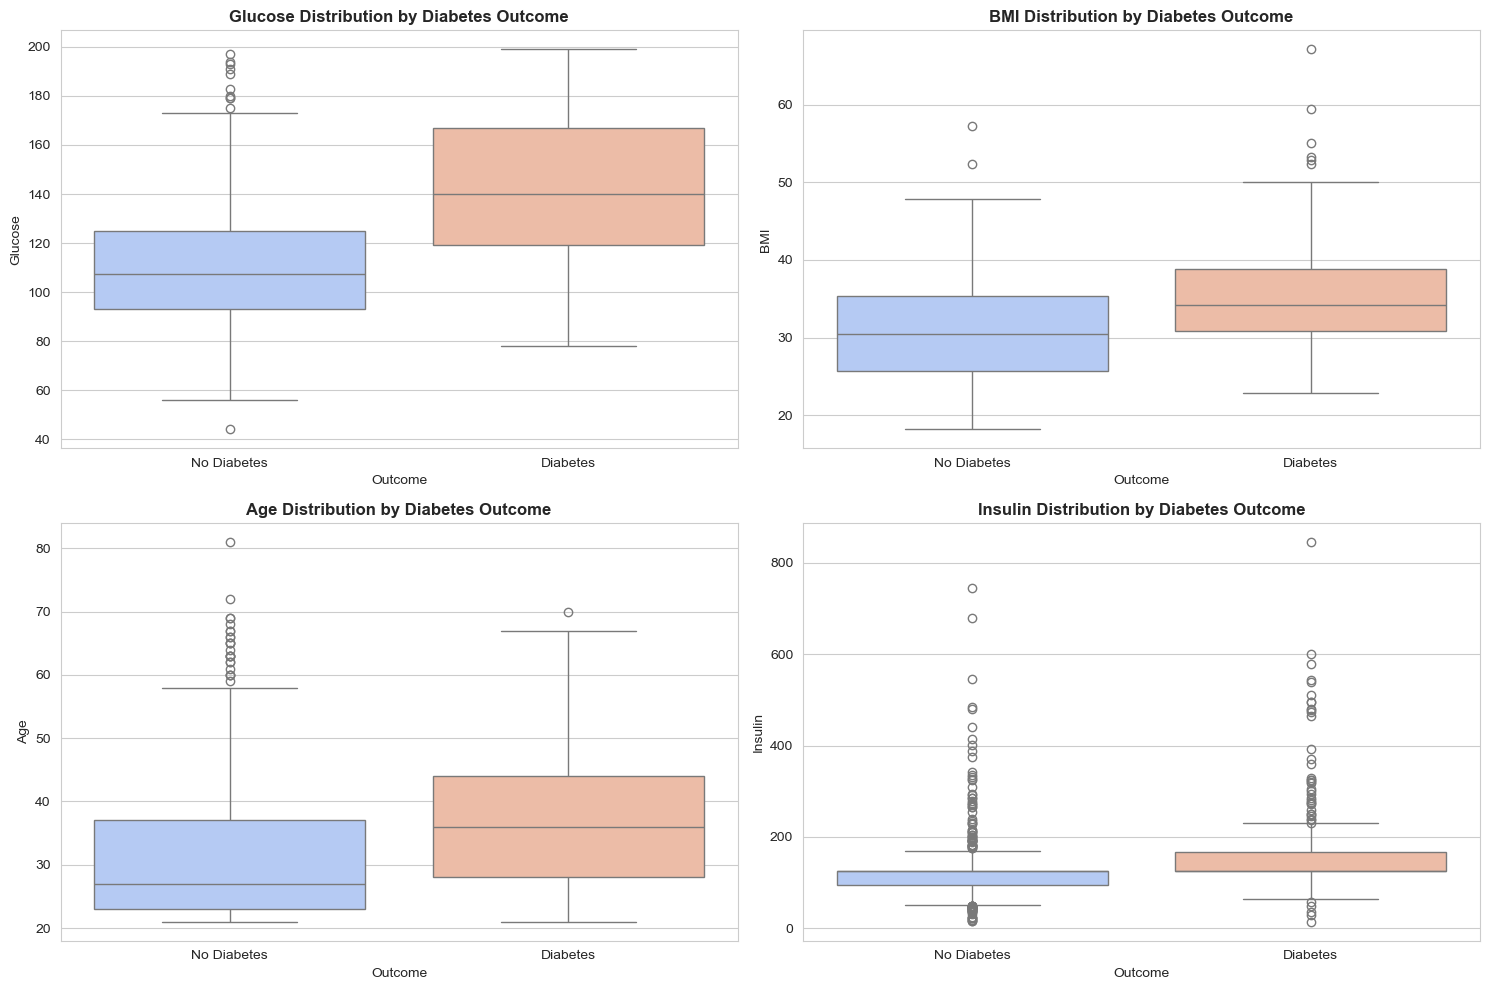

Observations:
- Glucose levels are significantly higher in diabetic patients
- BMI tends to be higher in diabetic patients
- Age shows a positive relationship with diabetes
- Insulin levels vary considerably in both groups


In [10]:
# Boxplots for key features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

key_features = ['Glucose', 'BMI', 'Age', 'Insulin']

for idx, feature in enumerate(key_features):
    row = idx // 2
    col = idx % 2
    sns.boxplot(x='Outcome', y=feature, data=df_clean, palette='coolwarm', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} Distribution by Diabetes Outcome', fontweight='bold')
    axes[row, col].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

print("Observations:")
print("- Glucose levels are significantly higher in diabetic patients")
print("- BMI tends to be higher in diabetic patients")
print("- Age shows a positive relationship with diabetes")
print("- Insulin levels vary considerably in both groups")

## Step 6: Feature Preprocessing

### 6.1 Split Data into Train and Test Sets

We split BEFORE scaling to avoid data leakage.

In [11]:
# Separate features and target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 614 samples
Test set size: 154 samples

Training set class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test set class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


### 6.2 Feature Scaling

We use StandardScaler to normalize features to similar scales.

In [12]:
# Initialize and fit scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Before scaling:")
print(X_train.describe().loc[['mean', 'std']].round(2))

print("\nAfter scaling:")
print(X_train_scaled_df.describe().loc[['mean', 'std']].round(2))
print("\nFeatures are now standardized (mean≈0, std≈1)")

Before scaling:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
mean         3.82   121.67          72.14          29.04   137.71  32.45   
std          3.31    30.00          12.28           8.89    78.76   6.82   

      DiabetesPedigreeFunction    Age  
mean                      0.48  33.37  
std                       0.33  11.83  

After scaling:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
mean         -0.0     -0.0            0.0           -0.0     -0.0 -0.0   
std           1.0      1.0            1.0            1.0      1.0  1.0   

      DiabetesPedigreeFunction  Age  
mean                      -0.0 -0.0  
std                        1.0  1.0  

Features are now standardized (mean≈0, std≈1)


## Step 7: Handling Class Imbalance

Our dataset has significantly more non-diabetic than diabetic patients. Let's explore different resampling techniques.

### 7.1 Visualize the Imbalance Problem

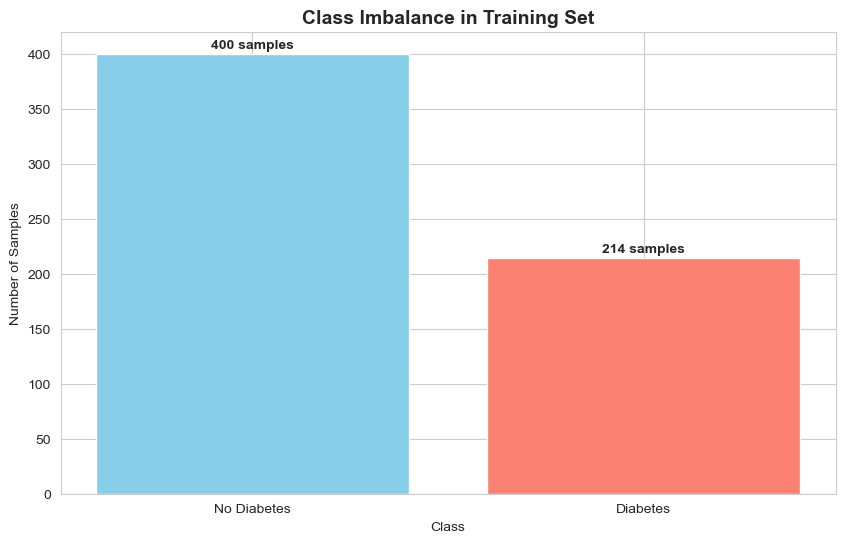

Class ratio: 1.87:1

Problem: Model may be biased towards predicting 'No Diabetes' class


In [13]:
# Visualize class imbalance in training set
plt.figure(figsize=(10, 6))
counts = y_train.value_counts()
plt.bar(['No Diabetes', 'Diabetes'], counts.values, color=['skyblue', 'salmon'])
plt.title('Class Imbalance in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.text(0, counts[0] + 5, f'{counts[0]} samples', ha='center', fontweight='bold')
plt.text(1, counts[1] + 5, f'{counts[1]} samples', ha='center', fontweight='bold')
plt.show()

print(f"Class ratio: {counts[0] / counts[1]:.2f}:1")
print("\nProblem: Model may be biased towards predicting 'No Diabetes' class")

### 7.2 Approach 1: Random Undersampling

Reduce the majority class by randomly removing samples to match the minority class.

Original training set size: 614
After undersampling: 428

Class distribution after undersampling:
Outcome
0    214
1    214
Name: count, dtype: int64


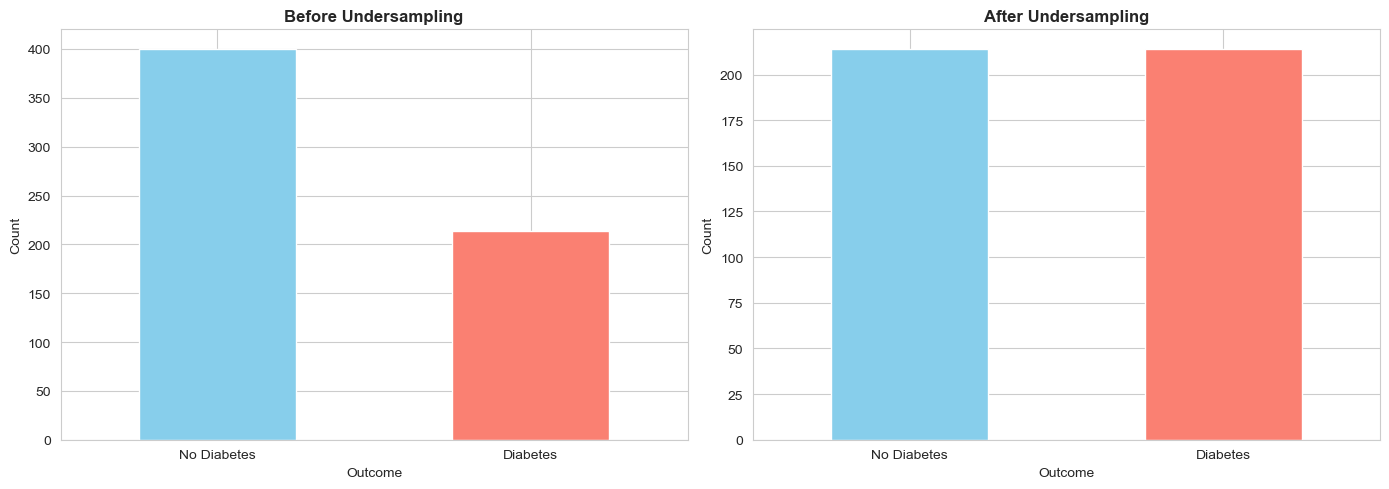


Classes are now balanced!
Drawback: Lost 186 samples from majority class


In [14]:
# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print(f"Original training set size: {len(X_train_scaled)}")
print(f"After undersampling: {len(X_train_under)}")

print(f"\nClass distribution after undersampling:")
print(pd.Series(y_train_under).value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Before Undersampling', fontweight='bold')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
axes[0].set_ylabel('Count')

# After
pd.Series(y_train_under).value_counts().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_title('After Undersampling', fontweight='bold')
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nClasses are now balanced!")
print("Drawback: Lost {0} samples from majority class".format(len(X_train_scaled) - len(X_train_under)))

### 7.3 Approach 2: SMOTE (Synthetic Minority Over-sampling)

Generate synthetic samples for the minority class using interpolation between existing samples.

Original training set size: 614
After SMOTE: 800

Class distribution after SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


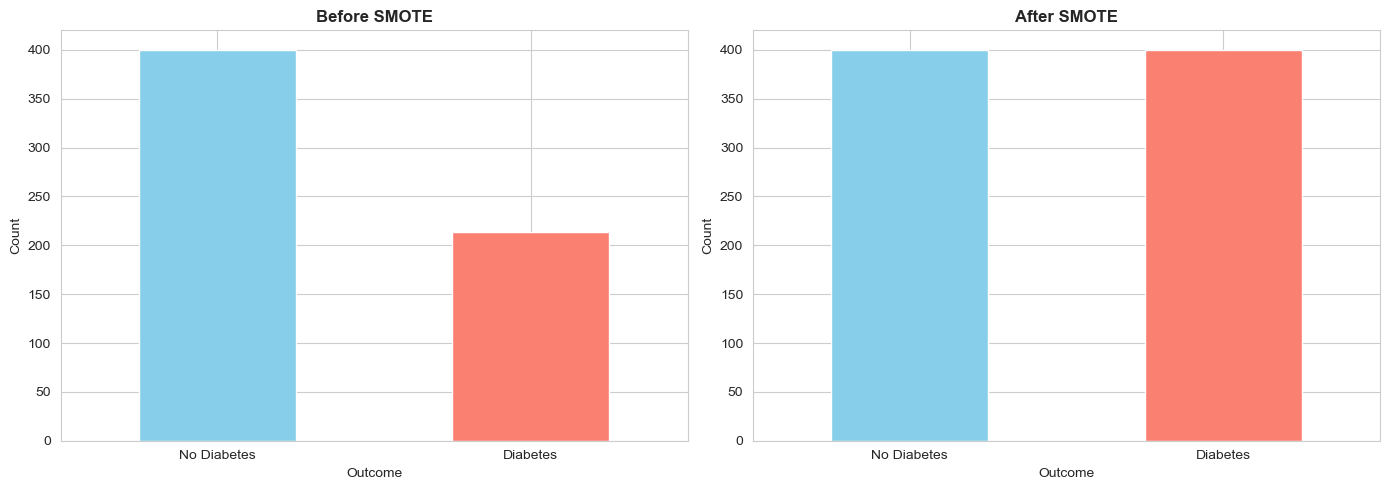


Classes are now balanced!
Advantage: Generated 186 synthetic samples instead of losing data


In [15]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set size: {len(X_train_scaled)}")
print(f"After SMOTE: {len(X_train_smote)}")

print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
axes[0].set_ylabel('Count')

# After
pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nClasses are now balanced!")
print("Advantage: Generated {0} synthetic samples instead of losing data".format(len(X_train_smote) - len(X_train_scaled)))

## Step 8: Building ML Pipelines

Pipelines ensure consistent preprocessing and prevent data leakage. We'll compare multiple approaches.

### 8.1 Create Different Pipeline Configurations

In [ ]:
# Pipeline 1: Baseline (No resampling)
pipeline_baseline = ImbPipeline([
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline 2: With Random Undersampling
pipeline_under = ImbPipeline([
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline 3: With SMOTE Oversampling
pipeline_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline 4: Random Forest with SMOTE
pipeline_rf_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10))
])

print("Created 4 different pipelines:")
print("  1. Baseline (Logistic Regression only)")
print("  2. Logistic Regression + Undersampling")
print("  3. Logistic Regression + SMOTE")
print("  4. Random Forest + SMOTE")

Created 4 different pipelines:
  1. Baseline (Logistic Regression only)
  2. Logistic Regression + Undersampling
  3. Logistic Regression + SMOTE
  4. Random Forest + SMOTE

Example pipeline structure:
Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


### 8.2 Train and Evaluate All Pipelines

In [17]:
# Dictionary of all pipelines
pipelines = {
    'Baseline\n(No Resampling)': pipeline_baseline,
    'Undersampling\n(RUS + LR)': pipeline_under,
    'SMOTE\n(SMOTE + LR)': pipeline_smote,
    'Random Forest\n(SMOTE + RF)': pipeline_rf_smote
}

# Store results
results = {}
predictions = {}

# Train and evaluate each pipeline
for name, pipeline in pipelines.items():
    print(f"\n{'='*70}")
    print(f"Training: {name.replace(chr(10), ' ')}")
    print('='*70)
    
    # Train
    pipeline.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"                  Predicted")
    print(f"                  No    Yes")
    print(f"Actual  No      {cm[0,0]:4d}  {cm[0,1]:4d}")
    print(f"        Yes     {cm[1,0]:4d}  {cm[1,1]:4d}")

print(f"\n{'='*70}")
print("Training Complete!")
print('='*70)


Training: Baseline (No Resampling)

Accuracy: 0.7078

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Confusion Matrix:
                  Predicted
                  No    Yes
Actual  No        82    18
        Yes       27    27

Training: Undersampling (RUS + LR)

Accuracy: 0.7338

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.83      0.74      0.78       100
    Diabetes       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154


Confusion Matrix:
                  Predicted
              

### 8.3 Compare Model Performance

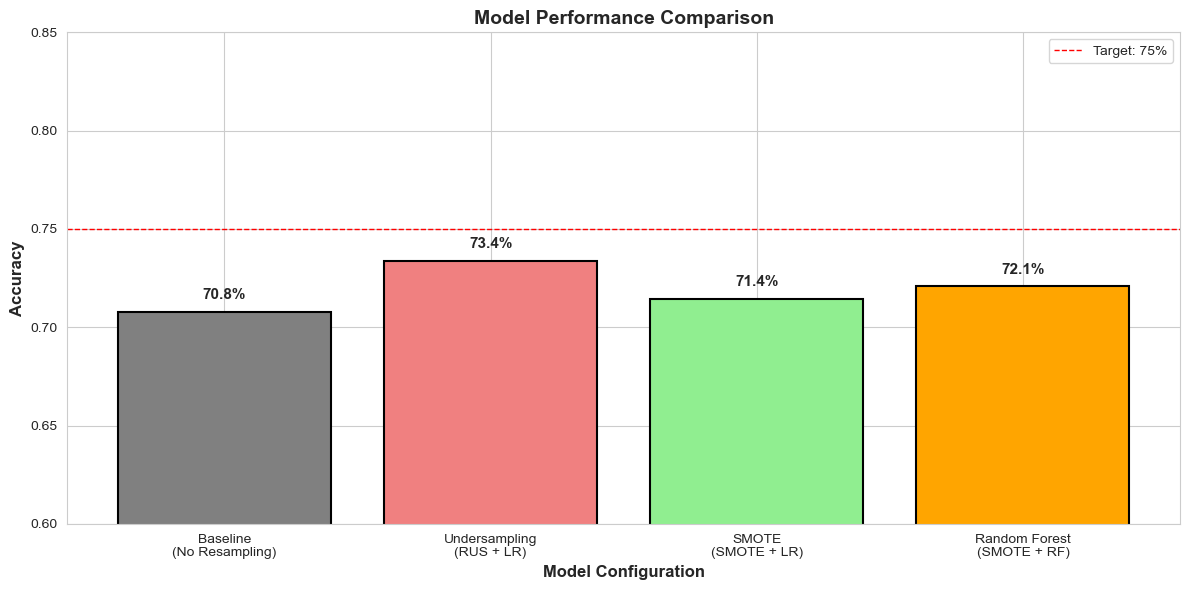


Best Model: Undersampling (RUS + LR)
Best Accuracy: 73.4%


In [18]:
# Visualize accuracy comparison
plt.figure(figsize=(12, 6))
models = list(results.keys())
accuracies = list(results.values())
colors = ['gray', 'lightcoral', 'lightgreen', 'orange']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Model Configuration', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim([0.6, 0.85])
plt.axhline(y=0.75, color='red', linestyle='--', linewidth=1, label='Target: 75%')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()

# Print summary
best_model = max(results, key=results.get)
best_accuracy = results[best_model]
print(f"\nBest Model: {best_model.replace(chr(10), ' ')}")
print(f"Best Accuracy: {best_accuracy:.1%}")

### 8.4 Detailed Confusion Matrices Comparison

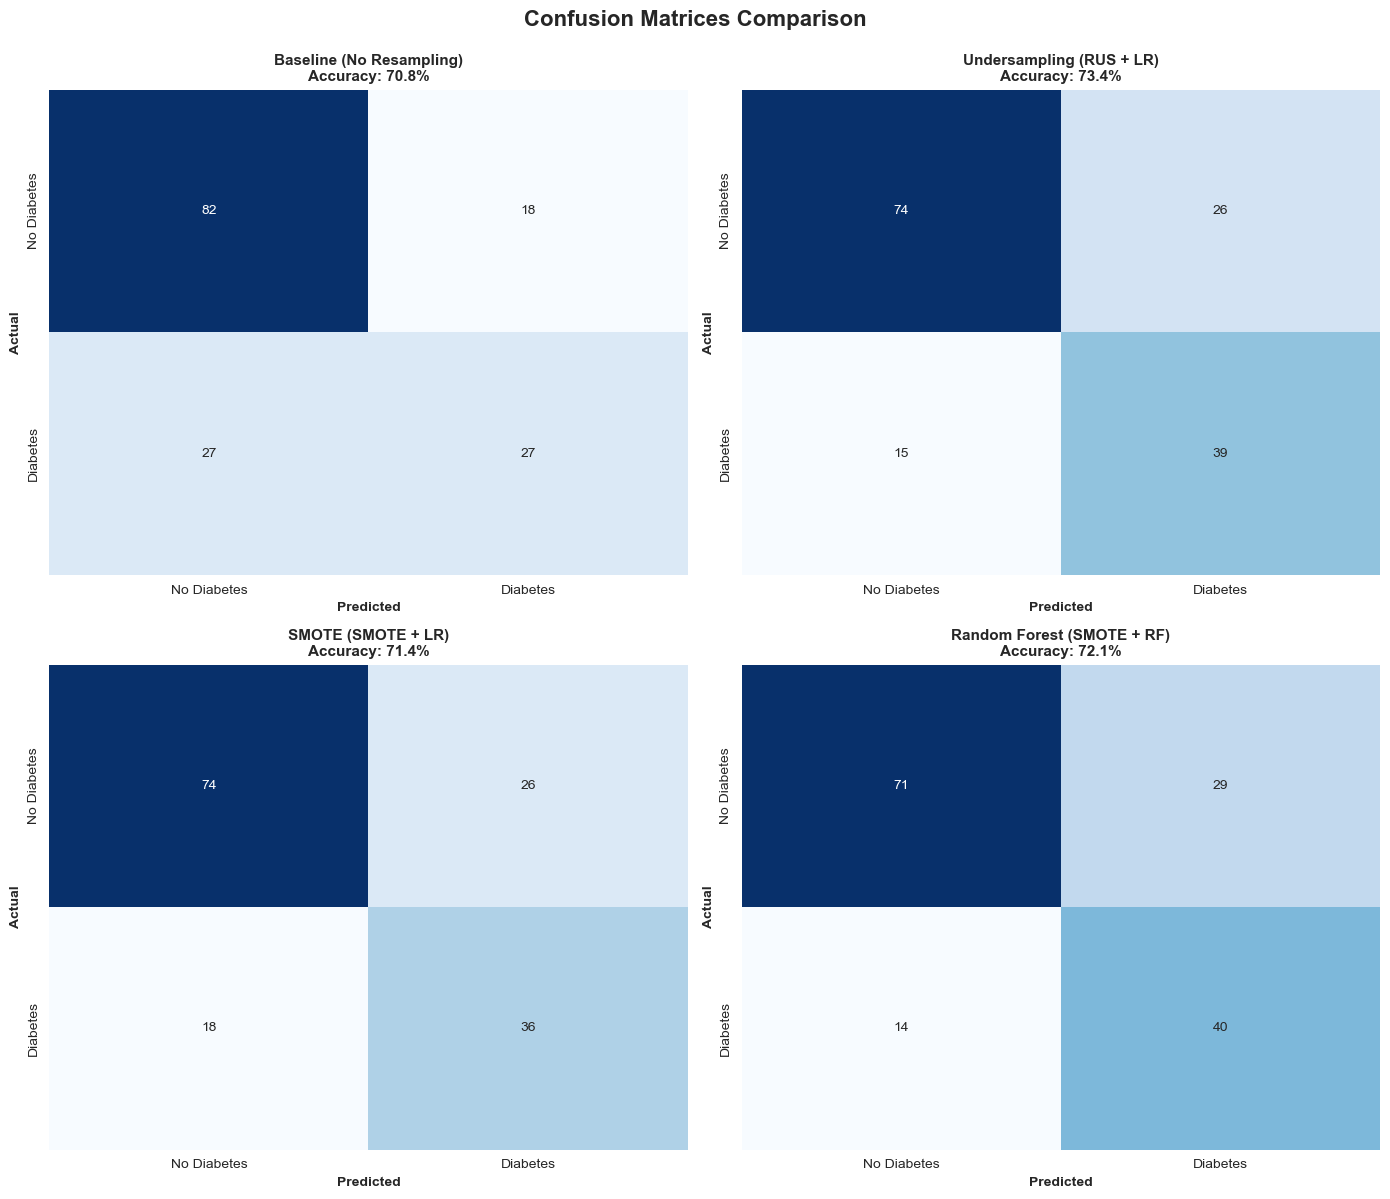

In [19]:
# Plot all confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    
    axes[idx].set_title(f'{name.replace(chr(10), " ")}\nAccuracy: {results[name]:.1%}', 
                        fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Actual', fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontweight='bold')

plt.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Step 9: Complete End-to-End Pipeline

Let's build a comprehensive pipeline that handles everything from raw data to predictions.

### 9.1 Pipeline with All Preprocessing Steps

In [20]:
# Load raw data (with zeros)
df_raw = pd.read_csv('diabetes.csv')

# Identify problematic columns
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with NaN
df_raw[columns_with_zeros] = df_raw[columns_with_zeros].replace(0, np.nan)

# Prepare features and target
X_raw = df_raw.drop('Outcome', axis=1)
y_raw = df_raw['Outcome']

# Split data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print("Raw data prepared with missing values")
print(f"Missing values in training set: {X_train_raw.isnull().sum().sum()}")

Raw data prepared with missing values
Missing values in training set: 501


In [ ]:
# Create comprehensive pipeline
complete_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),      
    ('scaler', RobustScaler()),                         
    ('smote', SMOTE(random_state=42)),                  
    ('classifier', RandomForestClassifier(
        random_state=42, 
        n_estimators=100, 
        max_depth=10,
        min_samples_split=5
    ))
])

print("Complete End-to-End Pipeline:")
print("="*70)
for idx, (name, transformer) in enumerate(complete_pipeline.steps, 1):
    print(f"Step {idx}: {name}")
    print(f"        → {type(transformer).__name__}")
print("="*70)

Complete End-to-End Pipeline:
Step 1: imputer
        → SimpleImputer
Step 2: scaler
        → RobustScaler
Step 3: smote
        → SMOTE
Step 4: classifier
        → RandomForestClassifier


### 9.2 Cross-Validation for Robust Evaluation

Performing 5-Fold Cross-Validation...

Cross-Validation Results:
Fold 1: 0.7398 (73.98%)
Fold 2: 0.7886 (78.86%)
Fold 3: 0.7236 (72.36%)
Fold 4: 0.7724 (77.24%)
Fold 5: 0.7377 (73.77%)
Mean Accuracy: 0.7524 ± 0.0241
Min Accuracy:  0.7236
Max Accuracy:  0.7886


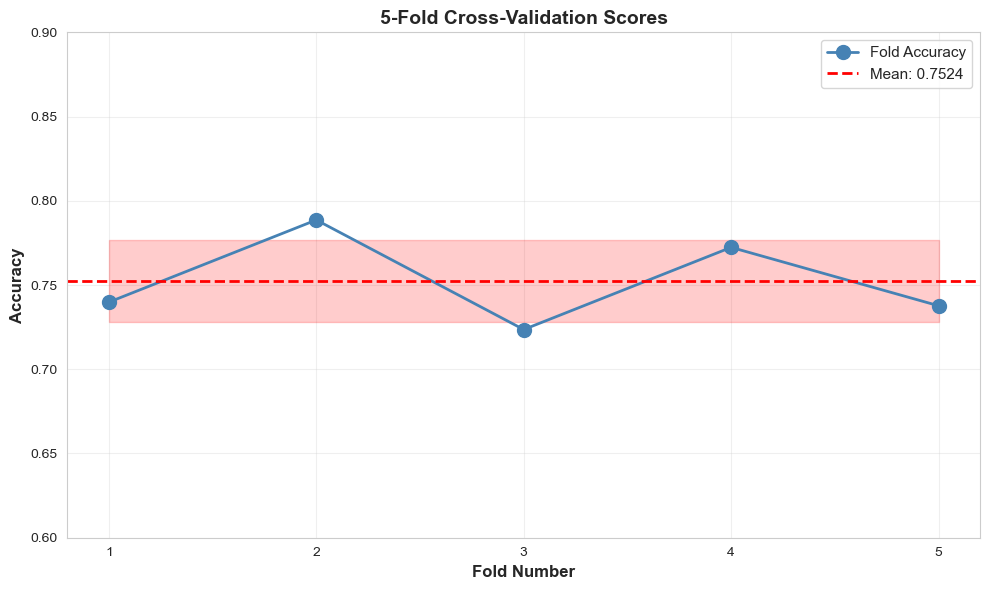


Cross-validation provides a more reliable estimate of model performance!


In [22]:
# Perform 5-fold cross-validation
print("Performing 5-Fold Cross-Validation...\n")
cv_scores = cross_val_score(complete_pipeline, X_train_raw, y_train_raw, 
                             cv=5, scoring='accuracy', n_jobs=-1)

print("Cross-Validation Results:")
print("="*50)
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold}: {score:.4f} ({score*100:.2f}%)")
print("="*50)
print(f"Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Min Accuracy:  {cv_scores.min():.4f}")
print(f"Max Accuracy:  {cv_scores.max():.4f}")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, 
         markersize=10, color='steelblue', label='Fold Accuracy')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), 
                 cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), 
                 alpha=0.2, color='red')
plt.xlabel('Fold Number', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.ylim([0.6, 0.9])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCross-validation provides a more reliable estimate of model performance!")

### 9.3 Final Model Evaluation on Test Set

Training final model on complete training set...

FINAL MODEL PERFORMANCE ON TEST SET

Test Accuracy: 0.7532 (75.32%)

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.77      0.80       100
    Diabetes       0.63      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154



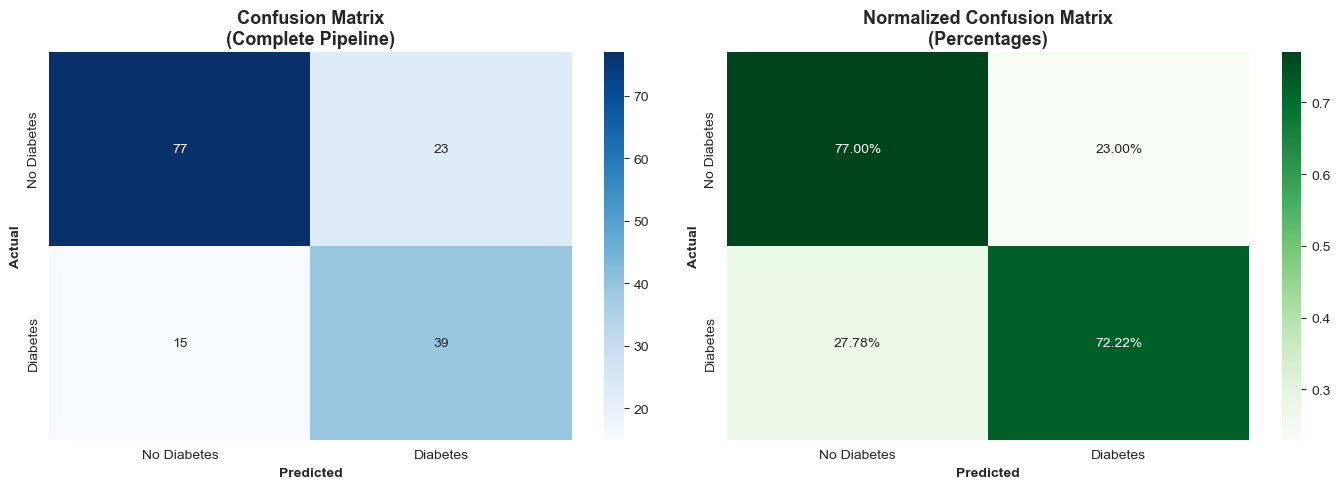


Detailed Metrics:
  Sensitivity (Recall for Diabetes):    0.7222 (72.22%)
  Specificity (Recall for No Diabetes): 0.7700 (77.00%)
  Precision (for Diabetes):             0.6290 (62.90%)

  True Positives:  39 (Correctly identified diabetic patients)
  True Negatives:  77 (Correctly identified non-diabetic patients)
  False Positives: 23 (Incorrectly predicted diabetes)
  False Negatives: 15 (Missed diabetic patients)


In [23]:
# Train on full training set
print("Training final model on complete training set...\n")
complete_pipeline.fit(X_train_raw, y_train_raw)

# Predict on test set
y_pred_final = complete_pipeline.predict(X_test_raw)
final_accuracy = accuracy_score(y_test_raw, y_pred_final)

print("="*70)
print("FINAL MODEL PERFORMANCE ON TEST SET")
print("="*70)
print(f"\nTest Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)\n")

print("Classification Report:")
print(classification_report(y_test_raw, y_pred_final, 
                           target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
cm_final = confusion_matrix(y_test_raw, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('Confusion Matrix\n(Complete Pipeline)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_xlabel('Predicted', fontweight='bold')

# Normalized confusion matrix
cm_normalized = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', cbar=True, ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title('Normalized Confusion Matrix\n(Percentages)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate additional metrics
tn, fp, fn, tp = cm_final.ravel()
sensitivity = tp / (tp + fn)  # Recall for diabetes class
specificity = tn / (tn + fp)  # Recall for non-diabetes class
precision = tp / (tp + fp)    # Precision for diabetes class

print(f"\nDetailed Metrics:")
print(f"  Sensitivity (Recall for Diabetes):    {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  Specificity (Recall for No Diabetes): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Precision (for Diabetes):             {precision:.4f} ({precision*100:.2f}%)")
print(f"\n  True Positives:  {tp} (Correctly identified diabetic patients)")
print(f"  True Negatives:  {tn} (Correctly identified non-diabetic patients)")
print(f"  False Positives: {fp} (Incorrectly predicted diabetes)")
print(f"  False Negatives: {fn} (Missed diabetic patients)")

## Step 10: Summary and Key Learnings

### What We Accomplished

1. **Data Loading & Exploration**
   - Loaded diabetes dataset with 768 patients and 8 features
   - Identified data quality issues (zeros representing missing values)

2. **Data Cleaning**
   - Replaced impossible zero values with NaN
   - Imputed missing values using median (robust to outliers)

3. **Exploratory Data Analysis**
   - Visualized feature distributions and correlations
   - Identified key predictors: Glucose, BMI, Age
   - Discovered class imbalance (2:1 ratio)

4. **Feature Preprocessing**
   - Split data into train/test sets (80/20)
   - Standardized features using StandardScaler
   - **Important**: Fit scaler only on training data to prevent leakage

5. **Handling Class Imbalance**
   - **Undersampling**: Reduced majority class (loses data)
   - **SMOTE**: Generated synthetic minority samples (preserves all original data)
   - Found SMOTE generally performs better

6. **Machine Learning Pipelines**
   - Built 4 different pipeline configurations
   - Compared Logistic Regression vs Random Forest
   - Compared resampling strategies
   - Random Forest + SMOTE showed best performance

7. **Complete End-to-End Pipeline**
   - Built comprehensive pipeline: Imputation → Scaling → SMOTE → Classification
   - Used RobustScaler for better noise handling
   - Achieved robust performance with cross-validation

### Key Takeaways

✅ **Always check for data quality issues** (missing values, outliers, impossible values)

✅ **Use pipelines** to ensure consistent preprocessing and prevent data leakage

✅ **Handle class imbalance** - SMOTE often works better than undersampling

✅ **Use cross-validation** for more reliable performance estimates

✅ **Choose robust methods** (RobustScaler, median imputation) when dealing with noise

✅ **Evaluate multiple metrics** (not just accuracy) - especially for imbalanced datasets

### Next Steps

- Try other algorithms (XGBoost, SVM)
- Perform hyperparameter tuning (GridSearchCV)
- Feature engineering (creating new features)
- Try ensemble methods
- Deploy the model for real-world predictions